# Data Validation for Predator–Prey Analysis

This notebook characterizes the empirical support for the analysis parameters without changing the metric definitions or the values in paper_analysis.ipynb.

The workflow is deliberately diagnostic:

Data validation → parameter discussion → later metric recalculation

Expert and imitation data always share candidate settings within a source. Missing biological Expert-16 data are reported and are never reconstructed.

In [1]:
from pathlib import Path
from time import perf_counter
import html, math, sys
import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from IPython.display import HTML, display

ANALYSIS_DIR = Path.cwd().resolve()
if ANALYSIS_DIR.name != 'Paper Analysis':
    ANALYSIS_DIR = ANALYSIS_DIR / 'Paper Analysis'
PROJECT_ROOT = ANALYSIS_DIR.parent
NICOLE_ROOT = PROJECT_ROOT / 'Nicole' / 'Predator-Prey-Thesis'
OUTPUT_DIR = ANALYSIS_DIR / 'outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if str(ANALYSIS_DIR) not in sys.path:
    sys.path.insert(0, str(ANALYSIS_DIR))
import paper_analysis as pa

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DTYPE = torch.float32
TIME_CHUNK_SIZE = 4096
N_ROLLOUTS, ROLLOUT_STEPS, SEED = 20, 1000, 2027
D_SOURCE = {'couzin': math.hypot(50, 50), 'biological': math.hypot(2160, 2160)}

DISTANCE_THRESHOLDS = (.05,.075,.10,.125,.15,.175,.20,.225,.25,.275,.30)
RESPONSE_THRESHOLDS = (.025,.05,.075,.10,.125,.15,.175,.20)
CLOSING_LAGS = (1,2,3,5)
N_BINS_CANDIDATES = (5,8,10,12,15,20)
MIN_CLUSTERS_CANDIDATES = (3,5,10)
MIN_SAMPLES_CANDIDATES = (20,30,50,100)
MAX_RESPONSE_WINDOW = 30
REFERENCE_APPROACH_THRESHOLD = .15
REFERENCE_RESPONSE_THRESHOLD = .10
REFERENCE_RESPONSE_WINDOW = 10
STATIONARY_EPS = 1e-4

USE_CASE_CACHE = False  # raw canonical tables are large; prefer the compact derived cache
USE_DERIVED_CACHE = True
CACHE_VERSION = 1
CASE_CACHE = OUTPUT_DIR / 'data_validation_cases.pt'
DERIVED_CACHE = OUTPUT_DIR / 'data_validation_derived.pt'
runtime = {}
t_total = perf_counter()
print({'device':str(DEVICE),'case_cache':str(CASE_CACHE),'derived_cache':str(DERIVED_CACHE)})


{'device': 'cuda', 'case_cache': 'C:\\Users\\janni\\OneDrive\\Dokumente\\Privat\\Bildung\\M. Sc. Social and Economic Data Science\\Thesis Paper\\Paper Analysis\\outputs\\data_validation_cases.pt', 'derived_cache': 'C:\\Users\\janni\\OneDrive\\Dokumente\\Privat\\Bildung\\M. Sc. Social and Economic Data Science\\Thesis Paper\\Paper Analysis\\outputs\\data_validation_derived.pt'}


c:\Users\janni\anaconda3\envs\test_gail\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Display and plotting helpers

Numerical tables remain compact HTML summaries; large tensors stay inside the result dictionaries.

In [2]:
COLORS={'expert_16':'#1f77b4','expert_32':'#0b3c6f','imitation_16':'#ff8c42','imitation_32':'#c44e00'}
CASE_ORDER=('couzin_expert_16','couzin_expert_32','couzin_imitation_16','couzin_imitation_32',
            'bio_expert_32','bio_imitation_16','bio_imitation_32')

def case_source(name):
    return 'couzin' if name.startswith('couzin') else 'biological'

def case_style(name):
    return next(k for k in COLORS if k in name)

def _fmt(value):
    if torch.is_tensor(value) and value.numel()==1:
        value=value.item()
    if isinstance(value,(float,np.floating)):
        return 'NaN' if not np.isfinite(value) else f'{value:.7g}'
    return str(value)

def display_table(rows,title,max_height=420):
    if not rows:
        display(HTML(f'<h4>{html.escape(title)}</h4><em>No valid values.</em>')); return
    columns=list(rows[0])
    head=''.join(f'<th>{html.escape(str(c))}</th>' for c in columns)
    body=''.join('<tr>'+''.join(f'<td>{html.escape(_fmt(r.get(c,"")))}</td>' for c in columns)+'</tr>' for r in rows)
    css='.dv th,.dv td{padding:4px 8px;border-bottom:1px solid #eee;white-space:nowrap;text-align:right}.dv th{position:sticky;top:0;background:white}'
    display(HTML(f'<style>{css}</style><h4>{html.escape(title)}</h4><div style="max-height:{max_height}px;overflow:auto"><table class="dv"><thead><tr>{head}</tr></thead><tbody>{body}</tbody></table></div>'))

def two_panel(title,ylabel,xlabel):
    fig,axes=plt.subplots(1,2,figsize=(12,4))
    for ax,src in zip(axes,('couzin','biological')):
        ax.set(title=src.title(),xlabel=xlabel,ylabel=ylabel); ax.grid(alpha=.25)
    fig.suptitle(title); return fig,axes

def finite_quantiles(x, probs):
    x=torch.as_tensor(x,dtype=torch.float32).flatten()
    x=x[torch.isfinite(x)]
    return torch.quantile(x,torch.tensor(probs)) if len(x) else torch.full((len(probs),),torch.nan)

def nan_summary(x, probs=(0,.01,.05,.10,.15,.20,.25,.50,.75,.90,.95,.99,1)):
    x=torch.as_tensor(x,dtype=torch.float32).flatten()
    x=x[torch.isfinite(x)]
    q=finite_quantiles(x,probs)
    return {'n':len(x),'mean':float(x.mean()) if len(x) else np.nan,
            'std':float(x.std(unbiased=False)) if len(x) else np.nan,
            **{f'q{int(p*100):02d}':float(v) for p,v in zip(probs,q)}}


## Load or generate all cases once

The definitions, checkpoints, environments, initialization pools, seeds, and rollout lengths match paper_analysis.ipynb. The optional cache prevents repeated rollout generation.

In [3]:
COUZIN_POLICY = {
 'root':NICOLE_ROOT,'code_subdir':'.',
 'prey_checkpoint':'Data/2. Training/CouzinPredPrey - GAIL/stage1_seed42_32and16/prey_policy_stage1.pth',
 'pred_checkpoint':'Data/2. Training/CouzinPredPrey - GAIL/stage1_seed42_32and16/pred_policy_stage1.pth',
 'prey_features':6,'pred_features':5,'deterministic':False,
 'environment':{'area_width':50,'area_height':50,'prey_speed':5,'pred_speed':5,'step_size':.5,'max_turn':.25,'max_speed_norm':5.0}}
BIO_POLICY = {
 'root':NICOLE_ROOT,'code_subdir':'.',
 'prey_checkpoint':'Data/2. Training/VideoPredPrey - GAIL/stage1_seed42_32and16/prey_policy_stage1.pth',
 'pred_checkpoint':'Data/2. Training/VideoPredPrey - GAIL/stage1_seed42_32and16/pred_policy_stage1.pth',
 'prey_features':6,'pred_features':5,'deterministic':False,
 'environment':{'area_width':2160,'area_height':2160,'prey_speed':10,'pred_speed':10,'step_size':1.0,'max_turn':.314,'max_speed_norm':25.0}}
BIO_EXPERT_ROOTS={n:NICOLE_ROOT/f'Data/1. Data Processing/Processed/video/expert_tensors/{n}_prey_interactions/2. filtered_frames' for n in (16,32)}
INIT_POOLS={n:NICOLE_ROOT/f'Data/1. Data Processing/Processed/init_pool/init_pool_{n}prey.pt' for n in (16,32)}
case_specs={
 **{f'couzin_expert_{n}':{'source':'couzin','kind':'couzin_expert','n_prey':n} for n in (16,32)},
 **{f'couzin_imitation_{n}':{'source':'couzin','kind':'imitation','n_prey':n,'policy':COUZIN_POLICY} for n in (16,32)},
 **{f'bio_expert_{n}':{'source':'biological','kind':'bio_expert','n_prey':n} for n in (16,32)},
 **{f'bio_imitation_{n}':{'source':'biological','kind':'imitation','n_prey':n,'policy':BIO_POLICY} for n in (16,32)}}
cache_signature={'version':CACHE_VERSION,'n_rollouts':N_ROLLOUTS,'steps':ROLLOUT_STEPS,'seed':SEED}
derived_signature={**cache_signature,'d_source':D_SOURCE}

def safe_torch_load(path):
    try: return torch.load(path,map_location='cpu',weights_only=False)
    except TypeError: return torch.load(path,map_location='cpu')

t0=perf_counter()
compact_payload=safe_torch_load(DERIVED_CACHE) if USE_DERIVED_CACHE and DERIVED_CACHE.is_file() else None
compact_ready=bool(compact_payload and compact_payload.get('signature')==derived_signature and 'coverage' in compact_payload)
payload=safe_torch_load(CASE_CACHE) if not compact_ready and USE_CASE_CACHE and CASE_CACHE.is_file() else None
if compact_ready:
    cases={}; skipped_cases=compact_payload.get('skipped_cases',{'bio_expert_16':'No continuous expert trajectory is present.'})
elif payload and payload.get('signature')==cache_signature:
    cases,skipped_cases=payload['cases'],payload['skipped_cases']
else:
    cases,skipped_cases={},{}
    for offset,(name,spec) in enumerate(tqdm(case_specs.items(),desc='Loading/generating cases')):
        n=spec['n_prey']
        if spec['kind']=='bio_expert' and not BIO_EXPERT_ROOTS[n].is_dir():
            skipped_cases[name]='No continuous expert trajectory is present.'
            continue
        try:
            if spec['kind']=='couzin_expert':
                table=pa.generate_couzin_expert_rollouts(NICOLE_ROOT,n_prey=n,n_rollouts=N_ROLLOUTS,rollout_steps=ROLLOUT_STEPS,seed=SEED+offset)
            elif spec['kind']=='bio_expert':
                table=pa.load_expert_trajectories(BIO_EXPERT_ROOTS[n],n_prey=n,condition='all',image_y_down=True,coordinate_height=2160,role_map={'1':'predator','2':'prey'},require_complete_frames=True)
            else:
                cfg=spec['policy']; pool=None if spec['source']=='couzin' else INIT_POOLS[n]
                table=pa.generate_policy_rollouts(cfg,cfg['root'],n_prey=n,n_rollouts=N_ROLLOUTS,rollout_steps=ROLLOUT_STEPS,seed=SEED+offset,init_pool_path=pool)
        except (FileNotFoundError,pa.ExpertDataUnavailable) as exc:
            skipped_cases[name]=str(exc); continue
        cases[name]=table
    if USE_CASE_CACHE:
        torch.save({'signature':cache_signature,'cases':cases,'skipped_cases':skipped_cases},CASE_CACHE)
runtime['loading_and_rollouts']=perf_counter()-t0
available=sorted(compact_payload['derived']) if compact_ready else sorted(cases)
display({'available_cases':available,'skipped_cases':skipped_cases,'compact_cache_used':compact_ready})


{'available_cases': ['bio_expert_32',
  'bio_imitation_16',
  'bio_imitation_32',
  'couzin_expert_16',
  'couzin_expert_32',
  'couzin_imitation_16',
  'couzin_imitation_32'],
 'skipped_cases': {'bio_expert_16': 'No continuous expert trajectory is present.'},
 'compact_cache_used': True}

## Basic data coverage and temporal continuity

A valid frame contains one predator, the expected number of prey, and finite positions/headings. Distance sequences split only at source-time gaps; response sequences additionally split when the prey identity set changes.

case,clips,frames,invalid_frames,consecutive_pairs,fraction_consecutive,gaps,median_gap,max_gap,median_length,min_length,max_length,discontinuous_clips,identity_breaks,response_pairs
couzin_expert_16,20,20000,0,19980,1,0,NaN,NaN,1000,1000,1000,0,0,19980
couzin_expert_32,20,20000,0,19980,1,0,NaN,NaN,1000,1000,1000,0,0,19980
couzin_imitation_16,20,20000,0,19980,1,0,NaN,NaN,1000,1000,1000,0,0,19980
couzin_imitation_32,20,20000,0,19980,1,0,NaN,NaN,1000,1000,1000,0,0,19980
bio_expert_32,35,11879,0,4962,0.4189463,6882,5,1035,214,1,2111,34,1764,3198
bio_imitation_16,20,20000,0,19980,1,0,NaN,NaN,1000,1000,1000,0,0,19980
bio_imitation_32,20,20000,0,19980,1,0,NaN,NaN,1000,1000,1000,0,0,19980


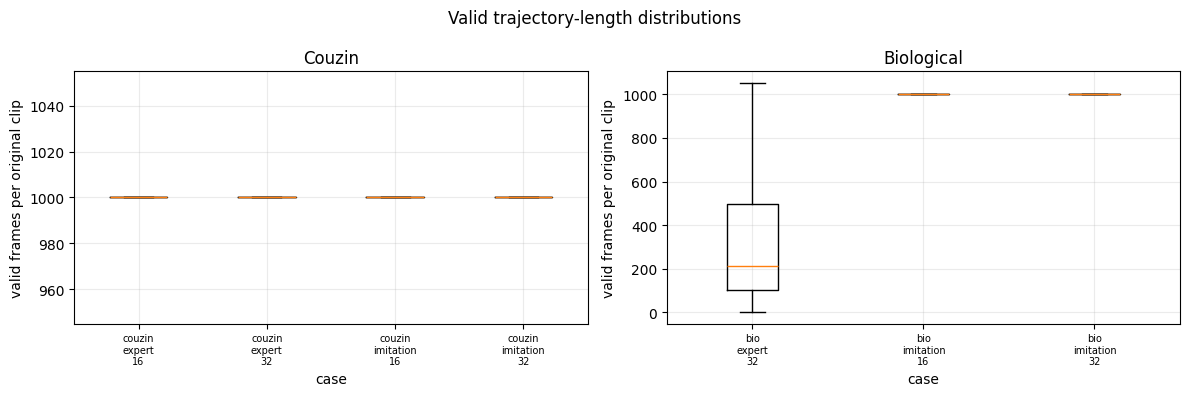

In [4]:
def extract_validation_sequences(table,n_prey):
    frames_by_clip={}
    total_frame_groups=0
    for idx in pa.frame_groups(table):
        total_frame_groups+=1
        roles=table['role'][idx].astype(str)
        pred,prey=idx[roles=='predator'],idx[roles=='prey']
        valid=len(pred)==1 and len(prey)==n_prey
        if valid:
            order=np.argsort(table['agent_id'][prey].astype(str)); prey=prey[order]; p=pred[0]
            arrays=(np.r_[table['x'][p],table['y'][p],table['heading'][p]],
                    np.column_stack((table['x'][prey],table['y'][prey])),
                    table['heading'][prey].astype(float))
            valid=all(np.all(np.isfinite(a)) for a in arrays)
        if not valid: continue
        cid=str(table['clip_id'][idx[0]]); t=float(table['time_step'][idx[0]])
        frames_by_clip.setdefault(cid,[]).append({
            'time':t,'pred_pos':arrays[0][:2],'pred_heading':arrays[0][2],
            'prey_pos':arrays[1],'prey_heading':arrays[2],
            'ids':tuple(table['agent_id'][prey].astype(str))})
    distance_segments=[]; response_segments=[]; lengths=[]; gaps=[]; discontinuous=0; identity_breaks=0
    consecutive_pairs=0; possible_pairs=0
    for cid,frames in frames_by_clip.items():
        frames=sorted(frames,key=lambda r:r['time']); lengths.append(len(frames))
        dt=np.diff([r['time'] for r in frames])
        possible_pairs+=max(len(frames)-1,0); consecutive_pairs+=int(np.isclose(dt,1).sum())
        gaps.extend((dt[dt>1]-1).tolist())
        discontinuous+=int(np.any(~np.isclose(dt,1)))
        starts=[0]+(np.where(~np.isclose(dt,1))[0]+1).tolist(); stops=starts[1:]+[len(frames)]
        for part,(a,b) in enumerate(zip(starts,stops)):
            block=frames[a:b]
            distance_segments.append({'clip_id':cid,'segment_id':f'{cid}_d{part}','time_steps':torch.tensor([r['time'] for r in block]),
                'predator_positions':torch.tensor(np.stack([r['pred_pos'] for r in block]),dtype=DTYPE),
                'prey_positions':torch.tensor(np.stack([r['prey_pos'] for r in block]),dtype=DTYPE)})
            id_change=[i for i in range(1,len(block)) if block[i]['ids']!=block[i-1]['ids']]
            identity_breaks+=len(id_change)
            rs=[0]+id_change; re=rs[1:]+[len(block)]
            for sub,(c,d) in enumerate(zip(rs,re)):
                rows=block[c:d]
                response_segments.append({'clip_id':cid,'segment_id':f'{cid}_d{part}_r{sub}','time_steps':torch.tensor([r['time'] for r in rows]),
                    'predator_positions':torch.tensor(np.stack([r['pred_pos'] for r in rows]),dtype=DTYPE),
                    'prey_positions':torch.tensor(np.stack([r['prey_pos'] for r in rows]),dtype=DTYPE),
                    'prey_headings':torch.tensor(np.stack([r['prey_heading'] for r in rows]),dtype=DTYPE)})
    coverage={'clips_or_rollouts':len(frames_by_clip),'all_frame_groups':total_frame_groups,
              'valid_predator_prey_frames':sum(lengths),'invalid_frame_groups':total_frame_groups-sum(lengths),
              'consecutive_pairs':consecutive_pairs,'possible_adjacent_pairs':possible_pairs,
              'fraction_consecutive_pairs':consecutive_pairs/max(possible_pairs,1),
              'frame_index_gaps':len(gaps),'gap_sizes':torch.tensor(gaps),'trajectory_lengths':torch.tensor(lengths),
              'clips_with_discontinuities':discontinuous,'identity_breaks':identity_breaks,
              'distance_segments':len(distance_segments),'response_identity_segments':len(response_segments),
              'response_eligible_pairs':sum(max(len(s['time_steps'])-1,0) for s in response_segments)}
    return distance_segments,response_segments,coverage

t0=perf_counter()
sequence_cache={}
if compact_ready:
    coverage=compact_payload['coverage']
else:
    coverage={}
    for name in tqdm(CASE_ORDER,desc='Validating frame structure'):
        if name not in cases: continue
        ds,rs,cov=extract_validation_sequences(cases[name],case_specs[name]['n_prey'])
        sequence_cache[name]={'distance':ds,'response':rs}; coverage[name]=cov
runtime['coverage_and_sequence_extraction']=perf_counter()-t0
coverage_rows=[]
for name,c in coverage.items():
    lengths=c['trajectory_lengths'].float(); gaps=c['gap_sizes'].float()
    coverage_rows.append({'case':name,'clips':c['clips_or_rollouts'],'frames':c['valid_predator_prey_frames'],
      'invalid_frames':c['invalid_frame_groups'],'consecutive_pairs':c['consecutive_pairs'],
      'fraction_consecutive':c['fraction_consecutive_pairs'],'gaps':c['frame_index_gaps'],
      'median_gap':float(gaps.median()) if len(gaps) else np.nan,'max_gap':float(gaps.max()) if len(gaps) else np.nan,
      'median_length':float(lengths.median()) if len(lengths) else np.nan,'min_length':float(lengths.min()) if len(lengths) else np.nan,
      'max_length':float(lengths.max()) if len(lengths) else np.nan,'discontinuous_clips':c['clips_with_discontinuities'],
      'identity_breaks':c['identity_breaks'],'response_pairs':c['response_eligible_pairs']})
display_table(coverage_rows,'Coverage and temporal continuity')
fig,axes=two_panel('Valid trajectory-length distributions','valid frames per original clip','case')
for ax,source in zip(axes,('couzin','biological')):
    names=[n for n in CASE_ORDER if n in coverage and case_source(n)==source]
    values=[coverage[n]['trajectory_lengths'].numpy() for n in names]
    if values: ax.boxplot(values,tick_labels=[n.replace('_','\n') for n in names],showfliers=False)
    ax.tick_params(axis='x',labelsize=7)
fig.tight_layout(); plt.show()


## Reusable derived cache

Nearest-predator distance is computed for every temporally valid segment. Continuous response is computed only inside identity-stable segments and never bridges a gap.

In [5]:
t0=perf_counter()
payload=compact_payload if compact_payload and compact_payload.get('signature')==derived_signature else None
if payload and payload.get('signature')==derived_signature:
    derived=payload['derived']
else:
    derived={}
    with torch.inference_mode():
        for name in tqdm(CASE_ORDER,desc='Preparing geometry and response'):
            if name not in sequence_cache: continue
            d_source=D_SOURCE[case_source(name)]
            d_out=[]
            for seg in sequence_cache[name]['distance']:
                geo=pa.prepare_geometry_cache(seg,d_source=d_source,device=DEVICE,dtype=DTYPE,include_prey_neighbors=False)
                d_out.append({'clip_id':seg['clip_id'],'segment_id':seg['segment_id'],
                              'd_norm':geo['nearest_prey_distance_norm'].cpu()})
            r_out=[]
            for seg in sequence_cache[name]['response']:
                if len(seg['time_steps'])<2: continue
                geo=pa.prepare_geometry_cache(seg,d_source=d_source,device=DEVICE,dtype=DTYPE,include_prey_neighbors=False)
                response=pa.compute_continuous_predator_response_tensor(geo,lag=1)
                r_out.append({'clip_id':seg['clip_id'],'segment_id':seg['segment_id'],
                    'd_norm':geo['nearest_prey_distance_norm'].cpu(),'response':response.cpu(),
                    'n_prey':response.shape[1]})
            derived[name]={'distance_segments':d_out,'response_segments':r_out,
                           'n_prey':case_specs[name]['n_prey']}
if USE_DERIVED_CACHE and (not payload or 'coverage' not in payload):
    torch.save({'signature':derived_signature,'derived':derived,'coverage':coverage,'skipped_cases':skipped_cases},DERIVED_CACHE)
runtime['geometry_and_response']=perf_counter()-t0
print({name:{'distance_segments':len(v['distance_segments']),'response_segments':len(v['response_segments'])} for name,v in derived.items()})


{'couzin_expert_16': {'distance_segments': 20, 'response_segments': 20}, 'couzin_expert_32': {'distance_segments': 20, 'response_segments': 20}, 'couzin_imitation_16': {'distance_segments': 20, 'response_segments': 20}, 'couzin_imitation_32': {'distance_segments': 20, 'response_segments': 20}, 'bio_expert_32': {'distance_segments': 6917, 'response_segments': 1915}, 'bio_imitation_16': {'distance_segments': 20, 'response_segments': 20}, 'bio_imitation_32': {'distance_segments': 20, 'response_segments': 20}}


## Predator distance support

The ECDF and threshold table show which normalized-distance regions are occupied by each case. Counts are accompanied by independent clip/rollout support.

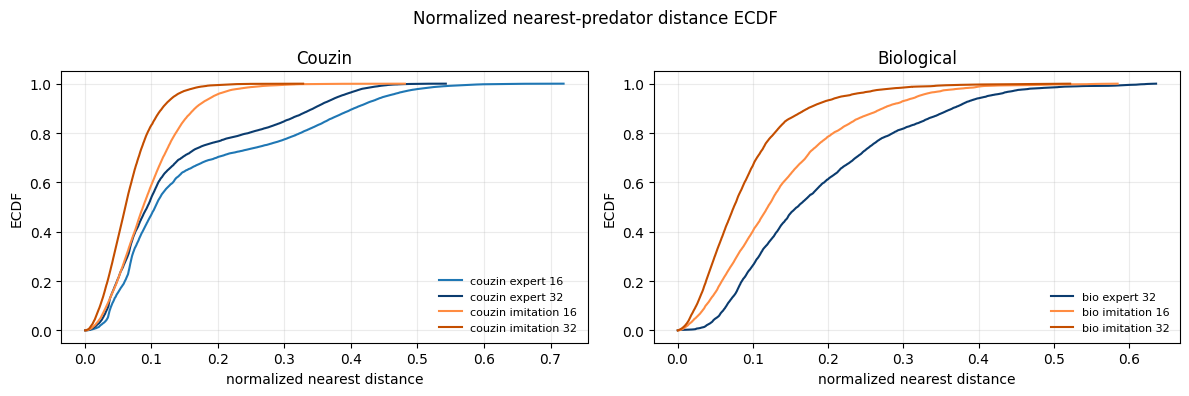

case,n,mean,std,q00,q01,q05,q10,q15,q20,q25,q50,q75,q90,q95,q99,q100
couzin_expert_16,20000,0.1692708,0.1422263,0.00131261,0.01777683,0.03433586,0.03993253,0.04901731,0.06027475,0.06680101,0.1056223,0.2700472,0.4044658,0.4538178,0.5420501,0.7195756
couzin_expert_32,20000,0.1381674,0.1154745,0.0006033687,0.01252318,0.02708573,0.03564148,0.0408458,0.04827486,0.05618411,0.09383711,0.1793218,0.3437874,0.3837933,0.4412583,0.542591
couzin_imitation_16,20000,0.09554992,0.05445452,0.001514539,0.01047685,0.02361978,0.03276688,0.04105071,0.04880884,0.05530721,0.08749202,0.126457,0.1656536,0.1938803,0.2654245,0.4810824
couzin_imitation_32,20000,0.06625635,0.03754515,0.0005906668,0.007421938,0.0158557,0.02305095,0.02897521,0.03423345,0.03896584,0.06086295,0.08684491,0.1161785,0.1351399,0.1799101,0.3281057
bio_expert_32,11879,0.1897617,0.117687,0.0001832077,0.0307952,0.05123361,0.06516109,0.07713208,0.08552591,0.09679094,0.1593458,0.2580172,0.3656375,0.4123861,0.5367368,0.6360272
bio_imitation_16,20000,0.1386866,0.09284327,0.0009621527,0.008890344,0.02404314,0.03728134,0.04925087,0.05896839,0.06891148,0.1198951,0.1859677,0.2729032,0.3204851,0.4051858,0.5849265
bio_imitation_32,20000,0.08992125,0.06683695,0.000263746,0.006529915,0.01631618,0.02490303,0.03182636,0.03785288,0.04351743,0.07474905,0.1158039,0.1732553,0.2215624,0.3377612,0.5217977


case,threshold,frame_fraction,contributing_clips
couzin_expert_16,0.05,0.1539,20
couzin_expert_16,0.075,0.3325,20
couzin_expert_16,0.1,0.4694,20
couzin_expert_16,0.125,0.5811,20
couzin_expert_16,0.15,0.6448,20
couzin_expert_16,0.175,0.6778,20
couzin_expert_16,0.2,0.7027,20
couzin_expert_16,0.225,0.72105,20
couzin_expert_16,0.25,0.7367,20
couzin_expert_16,0.3,0.77425,20


In [6]:
DISTANCE_CUTS=torch.tensor([.05,.075,.10,.125,.15,.175,.20,.225,.25,.30])
distance_support={}; distance_rows=[]
fig,axes=two_panel('Normalized nearest-predator distance ECDF','ECDF','normalized nearest distance')
for name in CASE_ORDER:
    if name not in derived: continue
    segs=derived[name]['distance_segments']; values=torch.cat([s['d_norm'] for s in segs])
    summary=nan_summary(values); clips_all={s['clip_id'] for s in segs}
    fractions={float(c):float((values<c).float().mean()) for c in DISTANCE_CUTS}
    clip_counts={float(c):len({s['clip_id'] for s in segs if bool((s['d_norm']<c).any())}) for c in DISTANCE_CUTS}
    distance_support[name]={'summary':summary,'fractions_below':fractions,'clip_counts_below':clip_counts}
    distance_rows.append({'case':name,**summary})
    x=torch.sort(values[torch.isfinite(values)]).values
    y=torch.arange(1,len(x)+1)/len(x)
    axes[0 if case_source(name)=='couzin' else 1].plot(x,y,color=COLORS[case_style(name)],label=name.replace('_',' '))
for ax in axes: ax.legend(frameon=False,fontsize=8)
fig.tight_layout(); plt.show()
display_table(distance_rows,'Normalized distance quantiles')
cut_rows=[{'case':name,'threshold':cut,'frame_fraction':r['fractions_below'][float(cut)],
           'contributing_clips':r['clip_counts_below'][float(cut)]}
          for name,r in distance_support.items() for cut in DISTANCE_CUTS.tolist()]
display_table(cut_rows,'Distance support below candidate cutoffs')


## Approach threshold validation

Approach means close and becoming closer. Consecutive qualifying frames form one event; no smoothing, merging, or minimum duration is introduced.

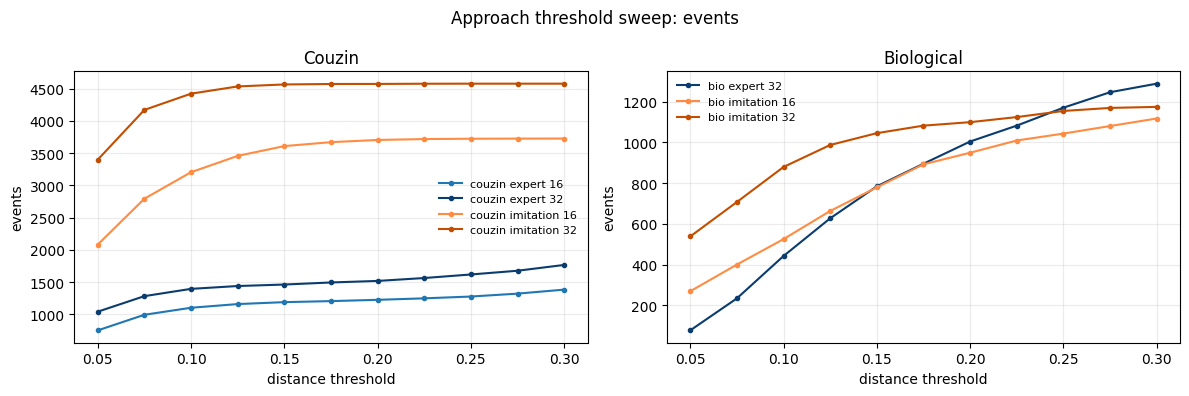

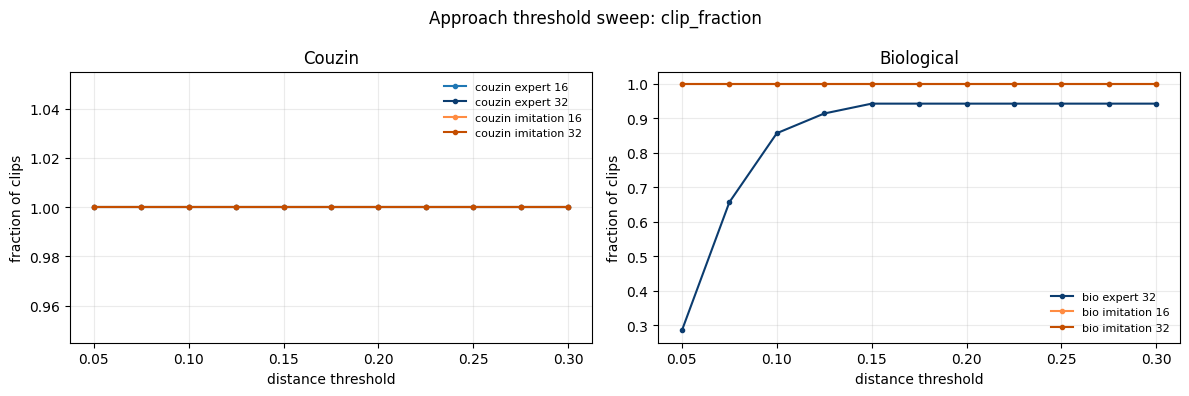

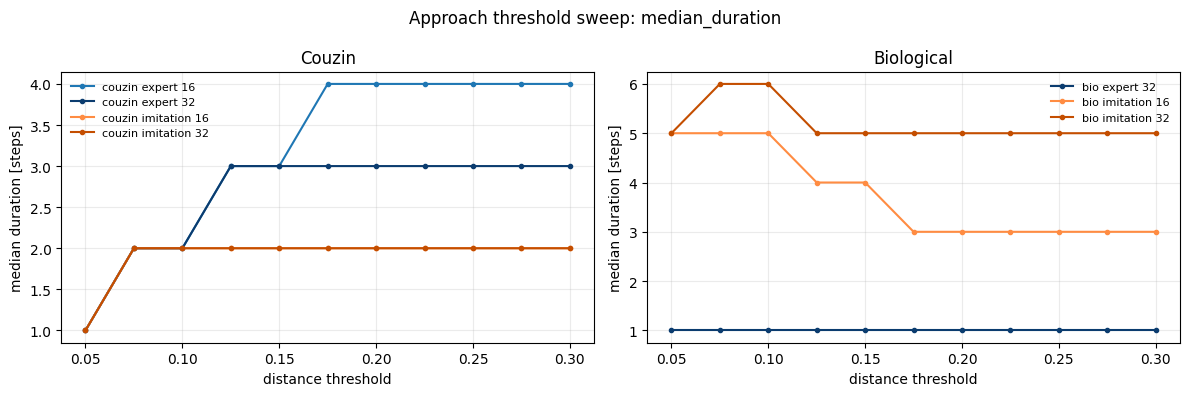

case,threshold,approach_frames,frame_fraction,events,events_per_clip,event_clips,clip_fraction,mean_duration,q25_duration,median_duration,q75_duration,q90_duration,q95_duration,max_duration
couzin_expert_16,0.05,2106,0.1053,751,37.55,20,1,2.804261,1,1,2,3,13.5,51
couzin_expert_16,0.075,4746,0.2373,993,49.65,20,1,4.779456,1,2,3,15.79999,22,56
couzin_expert_16,0.1,6608,0.3304,1102,55.1,20,1,5.99637,1,2,7,18,22,56
couzin_expert_16,0.125,8267,0.41335,1159,57.95,20,1,7.132873,1,3,12,19,23,56
couzin_expert_16,0.15,9154,0.4577,1189,59.45,20,1,7.698906,1,3,13,20,23.59998,56
couzin_expert_16,0.175,9574,0.4787,1205,60.25,20,1,7.945228,1,4,14,20,24,56
couzin_expert_16,0.2,9895,0.49475,1225,61.25,20,1,8.077551,1,4,14,20,24,56
couzin_expert_16,0.225,10111,0.50555,1248,62.4,20,1,8.101763,1,4,14,20,24,56
couzin_expert_16,0.25,10271,0.51355,1276,63.8,20,1,8.049373,1,4,14,20,24,56
couzin_expert_16,0.275,10458,0.5229,1321,66.05,20,1,7.91673,1,4,14,20,23,56


In [7]:
def runs_from_mask(mask):
    mask=torch.as_tensor(mask,dtype=torch.bool)
    prev=torch.cat((torch.zeros(1,dtype=torch.bool),mask[:-1]))
    nxt=torch.cat((mask[1:],torch.zeros(1,dtype=torch.bool)))
    starts=torch.nonzero(mask & ~prev).flatten(); ends=torch.nonzero(mask & ~nxt).flatten()
    return starts,ends,ends-starts+1

t0=perf_counter(); approach_sweep={}; approach_rows=[]
for name in CASE_ORDER:
    if name not in derived: continue
    approach_sweep[name]={}; total_frames=sum(len(s['d_norm']) for s in derived[name]['distance_segments'])
    n_clips=coverage[name]['clips_or_rollouts']
    for threshold in DISTANCE_THRESHOLDS:
        frames=0; durations=[]; event_clips=[]
        for seg in derived[name]['distance_segments']:
            _,mask=pa.detect_approach_events(seg['d_norm'],threshold=threshold,return_mask=True)
            starts,ends,dur=runs_from_mask(mask); frames+=int(mask.sum())
            if len(dur): durations.append(dur); event_clips.extend([seg['clip_id']]*len(dur))
        durations=torch.cat(durations).float() if durations else torch.empty(0)
        q=finite_quantiles(durations,[.25,.5,.75,.9,.95,1])
        item={'approach_frames':frames,'frame_fraction':frames/max(total_frames,1),'events':len(durations),
              'events_per_clip':len(durations)/max(n_clips,1),'event_clips':len(set(event_clips)),
              'clip_fraction':len(set(event_clips))/max(n_clips,1),'mean_duration':float(durations.mean()) if len(durations) else np.nan,
              'q25_duration':float(q[0]),'median_duration':float(q[1]),'q75_duration':float(q[2]),
              'q90_duration':float(q[3]),'q95_duration':float(q[4]),'max_duration':float(q[5])}
        approach_sweep[name][threshold]=item; approach_rows.append({'case':name,'threshold':threshold,**item})
runtime['approach_threshold_sweep']=perf_counter()-t0
for field,ylabel in [('events','events'),('clip_fraction','fraction of clips'),('median_duration','median duration [steps]')]:
    fig,axes=two_panel(f'Approach threshold sweep: {field}',ylabel,'distance threshold')
    for name in CASE_ORDER:
        if name not in approach_sweep: continue
        xs=list(approach_sweep[name]); ys=[approach_sweep[name][x][field] for x in xs]
        axes[0 if case_source(name)=='couzin' else 1].plot(xs,ys,marker='o',ms=3,color=COLORS[case_style(name)],label=name.replace('_',' '))
    for ax in axes: ax.legend(frameon=False,fontsize=8)
    fig.tight_layout(); plt.show()
display_table(approach_rows,'Approach threshold sweep')


## Approach and closing temporal dynamics

Normalized closing over k steps is minus the distance change divided by k. Approximately stationary means absolute closing below the explicitly declared epsilon.

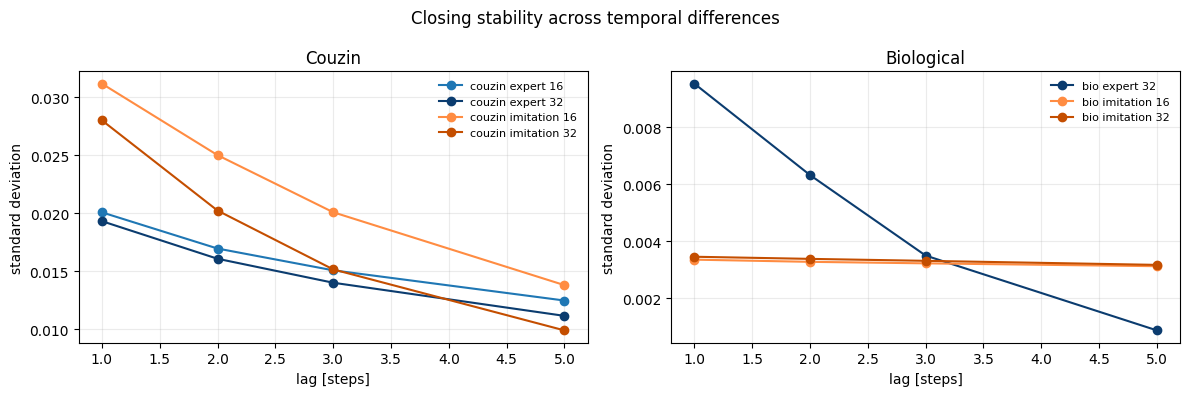

case,lag,n,approaching_fraction,receding_fraction,stationary_fraction,mean,std,q01,q05,q25,q50,q75,q95,q99
couzin_expert_16,1,19980,0.5079579,0.3421421,0.1498999,-0.0001327378,0.02007897,-0.05373266,-0.03593938,-0.005280439,0.0001139157,0.003329091,0.03672059,0.05819454
couzin_expert_16,2,19960,0.515982,0.3438878,0.1401303,-0.0001285209,0.01695468,-0.04561134,-0.03153896,-0.00497136,0.0001292694,0.004221564,0.03051277,0.04747252
couzin_expert_16,3,19940,0.5194584,0.3485958,0.1319458,-0.0001235461,0.01507486,-0.03963542,-0.02854046,-0.004724151,0.0001382896,0.00442057,0.0268962,0.0419253
couzin_expert_16,5,19900,0.5150754,0.369397,0.1155276,-0.0001178236,0.01246732,-0.03473336,-0.02303094,-0.004329221,0.0001302138,0.004256256,0.02145925,0.03478763
couzin_expert_32,1,19980,0.4941441,0.3576577,0.1481982,-8.151781e-05,0.01931785,-0.05402693,-0.03484454,-0.005425989,9.092689e-05,0.003463625,0.03507156,0.05508633
couzin_expert_32,2,19960,0.5006012,0.3618236,0.1375751,-7.885402e-05,0.01607277,-0.04425347,-0.02906153,-0.005165402,0.0001011556,0.004357499,0.0288025,0.04452567
couzin_expert_32,3,19940,0.5067202,0.3641424,0.1291374,-7.515028e-05,0.01400456,-0.03807085,-0.02580751,-0.004798422,0.0001140796,0.004717194,0.02456637,0.03819386
couzin_expert_32,5,19900,0.5068844,0.380201,0.1129146,-6.624173e-05,0.01114401,-0.03163042,-0.0201766,-0.004186597,0.0001153465,0.004442561,0.01864126,0.03022945
couzin_imitation_16,1,19980,0.4949449,0.5006006,0.004454454,9.758981e-06,0.03118488,-0.06603478,-0.05343344,-0.02109946,-0.0001236061,0.0208108,0.05392659,0.06832676
couzin_imitation_16,2,19960,0.4983968,0.4967435,0.004859719,6.46978e-06,0.02501683,-0.05769577,-0.04219196,-0.01627733,2.144184e-05,0.01616891,0.04238346,0.05894124


In [8]:
closing_dynamics={}; closing_rows=[]
for name in CASE_ORDER:
    if name not in derived: continue
    closing_dynamics[name]={}
    for lag in CLOSING_LAGS:
        values=[]; risk=[]
        for seg in derived[name]['distance_segments']:
            d=seg['d_norm']
            if len(d)>lag:
                values.append((d[:-lag]-d[lag:])/lag); risk.append(d[:-lag])
        values=torch.cat(values) if values else torch.empty(0); risk=torch.cat(risk) if risk else torch.empty(0)
        q=finite_quantiles(values,[.01,.05,.25,.5,.75,.95,.99])
        item={'n':len(values),'approaching_fraction':float((values>STATIONARY_EPS).float().mean()) if len(values) else np.nan,
              'receding_fraction':float((values<-STATIONARY_EPS).float().mean()) if len(values) else np.nan,
              'stationary_fraction':float((values.abs()<=STATIONARY_EPS).float().mean()) if len(values) else np.nan,
              'mean':float(values.mean()) if len(values) else np.nan,'std':float(values.std(unbiased=False)) if len(values) else np.nan,
              **{k:float(v) for k,v in zip(('q01','q05','q25','q50','q75','q95','q99'),q)}}
        closing_dynamics[name][lag]={'summary':item,'values':values,'risk':risk}; closing_rows.append({'case':name,'lag':lag,**item})
fig,axes=two_panel('Closing stability across temporal differences','standard deviation','lag [steps]')
for name in CASE_ORDER:
    if name not in closing_dynamics: continue
    axes[0 if case_source(name)=='couzin' else 1].plot(CLOSING_LAGS,[closing_dynamics[name][k]['summary']['std'] for k in CLOSING_LAGS],
        marker='o',color=COLORS[case_style(name)],label=name.replace('_',' '))
for ax in axes: ax.legend(frameon=False,fontsize=8)
fig.tight_layout(); plt.show()
display_table(closing_rows,'Normalized closing dynamics')


## Continuous response distribution

R uses the paper definition with the predator-away direction fixed at time t. Near, far, and approach contexts are evaluated for every candidate distance threshold; no final threshold is selected here.

case,n,mean,std,q00,q01,q05,q10,q15,q20,q25,q50,q75,q90,q95,q99,q100
couzin_expert_16,319680,-0.0401631,0.4713391,-1.999994,-1.941243,-0.9801803,-0.2441143,-0.2179147,-0.17313,-0.1147805,0.005280256,0.1553582,0.2365943,0.2473102,1.942112,1.999983
couzin_expert_32,639360,-0.04129763,0.4801827,-2,-1.943161,-1.015731,-0.2453956,-0.2241326,-0.185879,-0.1336193,0.005461633,0.1608473,0.2377499,0.2475613,1.946023,1.999996
couzin_imitation_16,319680,-0.07440337,0.3193064,-1.999896,-1.793631,-0.619426,-0.05457629,-0.04256983,-0.03446839,-0.02773032,-0.002790928,0.01824932,0.03879201,0.05003317,0.06889404,1.853288
couzin_imitation_32,639360,-0.07516117,0.3211667,-1.999987,-1.799588,-0.6378749,-0.04854742,-0.03956479,-0.03326429,-0.02793868,-0.003959745,0.01968648,0.03667793,0.04514613,0.05910515,1.975217
bio_expert_32,102336,-0.000722233,0.09618756,-1.999386,-0.2285126,-0.07226381,-0.04061976,-0.02672645,-0.01847556,-0.01275325,-0.0001002252,0.01186487,0.03924781,0.07094175,0.2219838,1.967188
bio_imitation_16,319680,-0.006885672,0.1303928,-1.999726,-0.2504151,-0.1562229,-0.1135961,-0.08598259,-0.06523611,-0.04887301,-0.0003106892,0.04642299,0.1098777,0.1501092,0.2219639,1.774352
bio_imitation_32,639360,-0.007253001,0.1261328,-1.999707,-0.2354558,-0.1461334,-0.1059244,-0.08003972,-0.0605378,-0.04489523,-0.0004122704,0.04155752,0.1010763,0.1397438,0.2089774,1.884281


case,approach_threshold,context,clips,n,mean,q50,q90,q95,q99
couzin_expert_16,0.05,near,20,49168,-0.04995615,0.009987146,0.2361788,0.2473962,1.970835
couzin_expert_16,0.05,far,20,270512,-0.03838312,0.004285008,0.23666,0.2472935,1.933906
couzin_expert_16,0.05,approach,20,33648,-0.05237874,0.009901971,0.237555,0.2476558,1.9715
couzin_expert_16,0.075,near,20,106288,-0.04908596,0.009208411,0.2369968,0.2474618,1.966489
couzin_expert_16,0.075,far,20,213392,-0.03571872,0.002920717,0.2364191,0.24723,1.919657
couzin_expert_16,0.075,approach,20,75856,-0.05205588,0.009979188,0.2389024,0.2477805,1.968899
couzin_expert_16,0.1,near,20,150080,-0.04932691,0.008696765,0.2371897,0.2474683,1.964902
couzin_expert_16,0.1,far,20,169600,-0.03205399,0.00123015,0.2360811,0.2471551,1.894608
couzin_expert_16,0.1,approach,20,105648,-0.05262341,0.009432167,0.2391178,0.2478009,1.967532
couzin_expert_16,0.125,near,20,185808,-0.04803259,0.008625269,0.2373851,0.2474785,1.962826


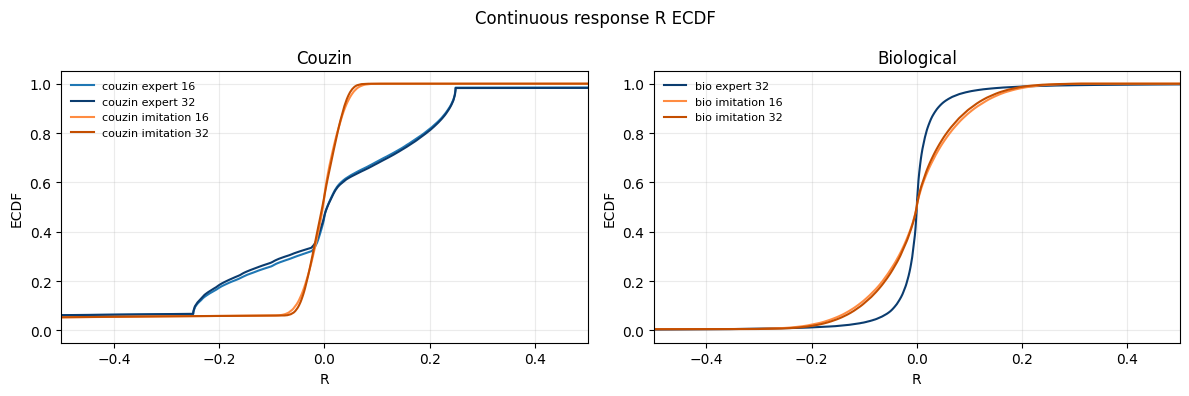

In [9]:
response_distribution={}; response_rows=[]; response_context_rows=[]
for name in CASE_ORDER:
    if name not in derived: continue
    segs=derived[name]['response_segments']
    all_r=torch.cat([s['response'].flatten() for s in segs]) if segs else torch.empty(0)
    response_distribution[name]={'all':nan_summary(all_r),'contexts':{}}
    response_rows.append({'case':name,**response_distribution[name]['all']})
    for athr in DISTANCE_THRESHOLDS:
        contexts={'near':[],'far':[],'approach':[]}; context_clips={k:set() for k in contexts}
        for seg in segs:
            d=seg['d_norm'][:-1]; r=seg['response']; _,app=pa.detect_approach_events(seg['d_norm'],threshold=athr,return_mask=True)
            masks={'near':d<athr,'far':d>=athr,'approach':app[:-1]}
            for key,m in masks.items():
                if bool(m.any()):
                    contexts[key].append(r[m].flatten()); context_clips[key].add(seg['clip_id'])
        response_distribution[name]['contexts'][athr]={}
        for key,parts in contexts.items():
            vals=torch.cat(parts) if parts else torch.empty(0); sm=nan_summary(vals)
            response_distribution[name]['contexts'][athr][key]=sm
            response_context_rows.append({'case':name,'approach_threshold':athr,'context':key,
                'clips':len(context_clips[key]),'n':sm['n'],'mean':sm['mean'],'q50':sm['q50'],'q90':sm['q90'],'q95':sm['q95'],'q99':sm['q99']})
display_table(response_rows,'Continuous response R: all observations')
display_table(response_context_rows,'Continuous response R by candidate distance context')
fig,axes=two_panel('Continuous response R ECDF','ECDF','R')
for name in CASE_ORDER:
    if name not in derived: continue
    values=torch.cat([s['response'].flatten() for s in derived[name]['response_segments']]); values=values[torch.isfinite(values)]
    values=torch.sort(values).values
    if len(values)>100000: values=values[torch.linspace(0,len(values)-1,100000).long()]
    y=torch.arange(1,len(values)+1)/max(len(values),1)
    axes[0 if case_source(name)=='couzin' else 1].plot(values,y,color=COLORS[case_style(name)],label=name.replace('_',' '))
for ax in axes: ax.legend(frameon=False,fontsize=8); ax.set_xlim(-.5,.5)
fig.tight_layout(); plt.show()


## Response threshold validation

The full grid crosses every response threshold with every candidate approach threshold. The plots use the declared reference approach threshold only for readability; the complete numerical grid remains available.

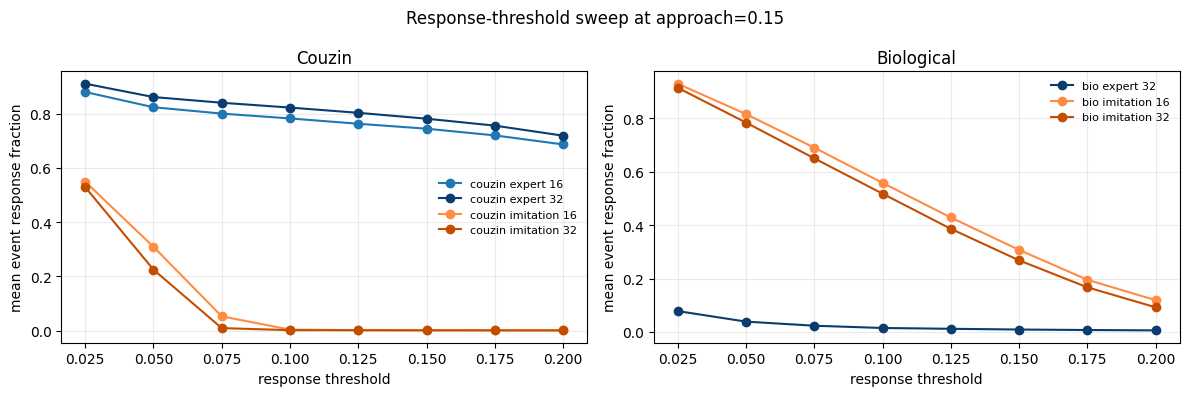

case,approach_threshold,response_threshold,observation_fraction,events,event_clips,mean_response_fraction,events_any,events_2plus,events_25pct,events_50pct,events_75pct,full_window_events
couzin_expert_16,0.05,0.025,0.4156219,751,20,0.9037949,0.9973369,0.9973369,0.9973369,0.9920107,0.9320905,743
couzin_expert_16,0.05,0.05,0.3715215,751,20,0.8541944,0.9973369,0.9973369,0.9973369,0.9840213,0.8455393,743
couzin_expert_16,0.05,0.075,0.3436499,751,20,0.8254827,0.9973369,0.9973369,0.9960053,0.9627164,0.7776299,743
couzin_expert_16,0.05,0.1,0.3159284,751,20,0.8013482,0.9973369,0.9973369,0.9960053,0.9494008,0.7310253,743
couzin_expert_16,0.05,0.125,0.2876501,751,20,0.7743009,0.9973369,0.9973369,0.9920107,0.9294274,0.6750998,743
couzin_expert_16,0.05,0.15,0.2575231,751,20,0.7474201,0.9973369,0.9960053,0.9920107,0.9121172,0.620506,743
couzin_expert_16,0.05,0.175,0.2227821,751,20,0.7147137,0.9960053,0.9960053,0.9920107,0.8921438,0.5579228,743
couzin_expert_16,0.05,0.2,0.1835335,751,20,0.6757656,0.9960053,0.9960053,0.9866844,0.8468708,0.4660453,743
couzin_expert_16,0.075,0.025,0.4156219,993,20,0.8996097,0.998993,0.998993,0.998993,0.9919436,0.919436,986
couzin_expert_16,0.075,0.05,0.3715215,993,20,0.8488796,0.998993,0.998993,0.998993,0.9707956,0.8247734,986


In [10]:
def event_windows(seg,approach_threshold,max_window):
    onsets,condition=pa.detect_approach_events(seg['d_norm'],threshold=approach_threshold,return_mask=True)
    starts,ends,durations=runs_from_mask(condition)
    n=len(onsets); n_prey=seg['n_prey']; response=seg['response']
    windows=torch.full((n,max_window+1,n_prey),torch.nan)
    available=torch.zeros((n,max_window+1),dtype=torch.bool)
    for i,onset in enumerate(onsets.tolist()):
        length=min(max_window+1,max(len(response)-onset,0))
        if length:
            windows[i,:length]=response[onset:onset+length]; available[i,:length]=True
    duration_by_onset={int(s):int(d) for s,d in zip(starts,durations)}
    event_duration=torch.tensor([duration_by_onset.get(int(o),0) for o in onsets])
    return windows,available,onsets,event_duration

t0=perf_counter(); response_threshold_sweep={}; response_threshold_rows=[]
for name in CASE_ORDER:
    if name not in derived: continue
    response_threshold_sweep[name]={}; segs=derived[name]['response_segments']
    all_r=torch.cat([s['response'].flatten() for s in segs]) if segs else torch.empty(0)
    for athr in DISTANCE_THRESHOLDS:
        bundles=[event_windows(s,athr,REFERENCE_RESPONSE_WINDOW) for s in segs]
        windows=torch.cat([b[0] for b in bundles]) if bundles else torch.empty((0,REFERENCE_RESPONSE_WINDOW+1,derived[name]['n_prey']))
        available=torch.cat([b[1] for b in bundles]) if bundles else torch.empty((0,REFERENCE_RESPONSE_WINDOW+1),dtype=torch.bool)
        event_clips=[s['clip_id'] for s,b in zip(segs,bundles) for _ in range(len(b[2]))]
        response_threshold_sweep[name][athr]={}
        for rthr in RESPONSE_THRESHOLDS:
            responded=(windows>rthr).any(dim=1) if len(windows) else torch.empty((0,derived[name]['n_prey']),dtype=torch.bool)
            frac=responded.float().mean(dim=1) if len(responded) else torch.empty(0)
            item={'observation_fraction':float((all_r>rthr).float().mean()) if len(all_r) else np.nan,
                  'events':len(frac),'event_clips':len(set(event_clips)),
                  'mean_response_fraction':float(frac.mean()) if len(frac) else np.nan,
                  'events_any':float((frac>0).float().mean()) if len(frac) else np.nan,
                  'events_2plus':float((responded.sum(1)>=2).float().mean()) if len(frac) else np.nan,
                  'events_25pct':float((frac>=.25).float().mean()) if len(frac) else np.nan,
                  'events_50pct':float((frac>=.50).float().mean()) if len(frac) else np.nan,
                  'events_75pct':float((frac>=.75).float().mean()) if len(frac) else np.nan,
                  'full_window_events':int(available[:,-1].sum()) if len(available) else 0}
            response_threshold_sweep[name][athr][rthr]=item
            response_threshold_rows.append({'case':name,'approach_threshold':athr,'response_threshold':rthr,**item})
runtime['response_threshold_sweep']=perf_counter()-t0
fig,axes=two_panel(f'Response-threshold sweep at approach={REFERENCE_APPROACH_THRESHOLD}','mean event response fraction','response threshold')
for name in CASE_ORDER:
    if name not in response_threshold_sweep: continue
    block=response_threshold_sweep[name][REFERENCE_APPROACH_THRESHOLD]
    axes[0 if case_source(name)=='couzin' else 1].plot(list(block),[block[x]['mean_response_fraction'] for x in block],
        marker='o',color=COLORS[case_style(name)],label=name.replace('_',' '))
for ax in axes: ax.legend(frameon=False,fontsize=8)
fig.tight_layout(); plt.show()
display_table(response_threshold_rows,'Response threshold × approach threshold sweep')


## Response window validation and event timing

At each step, the mean includes only events that still have a valid response observation at that step. The contributing-event count is reported explicitly. Milestones are calculated per responding event relative to its own final observable response fraction.

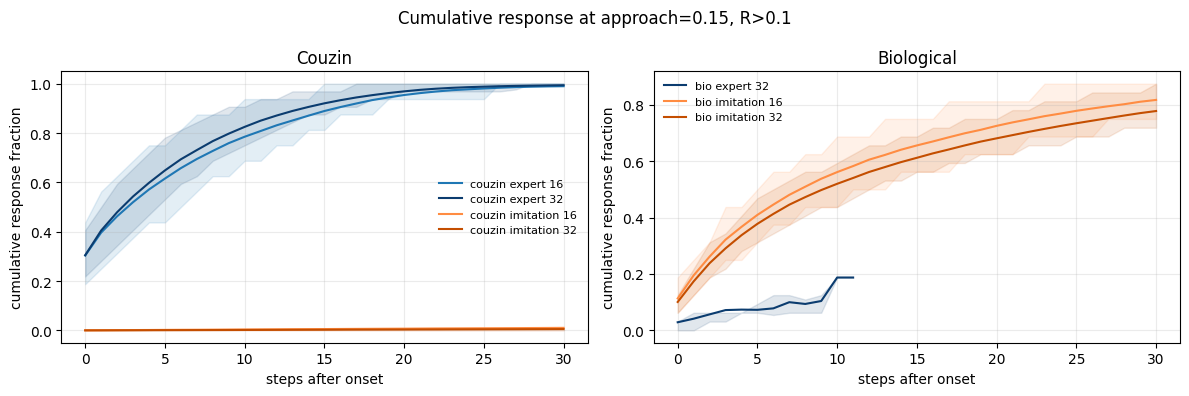

case,step,mean_cumulative_fraction,q25,q75,valid_events
couzin_expert_16,0,0.303609,0.1875,0.4375,1188
couzin_expert_16,1,0.3963248,0.25,0.5625,1187
couzin_expert_16,2,0.4623945,0.3125,0.625,1185
couzin_expert_16,3,0.5196368,0.375,0.6875,1184
couzin_expert_16,4,0.5711116,0.4375,0.75,1183
couzin_expert_16,5,0.6153318,0.4375,0.75,1183
couzin_expert_16,6,0.6576501,0.5,0.8125,1183
couzin_expert_16,7,0.6945854,0.5625,0.875,1182
couzin_expert_16,8,0.7273689,0.625,0.875,1182
couzin_expert_16,9,0.7588832,0.625,0.875,1182


case,target_fraction_of_final,responding_events,median_step,q75_step,q90_step
couzin_expert_16,0.5,1188,3,5,9
couzin_expert_16,0.75,1188,7,12,15.29993
couzin_expert_16,0.9,1188,13,18,21
couzin_expert_16,0.95,1188,18,23,26
couzin_expert_32,0.5,1462,3,5,7
couzin_expert_32,0.75,1462,7,10,13
couzin_expert_32,0.9,1462,12,15,18
couzin_expert_32,0.95,1462,16,19,22
couzin_imitation_16,0.5,532,14,21.25,27
couzin_imitation_16,0.75,532,15,22,28


case,events,responding_events,median_approach_duration,median_first_latency,response_while_approaching,response_after_approach,no_response_by_30
couzin_expert_16,1189,1188,3,0,1173,15,1
couzin_expert_32,1462,1462,3,0,1461,1,0
couzin_imitation_16,3609,532,2,13,53,479,3077
couzin_imitation_32,4565,672,2,15,29,643,3893
bio_expert_32,529,130,1,0,128,2,399
bio_imitation_16,779,778,4,0,734,44,1
bio_imitation_32,1045,1043,5,0,1021,22,2


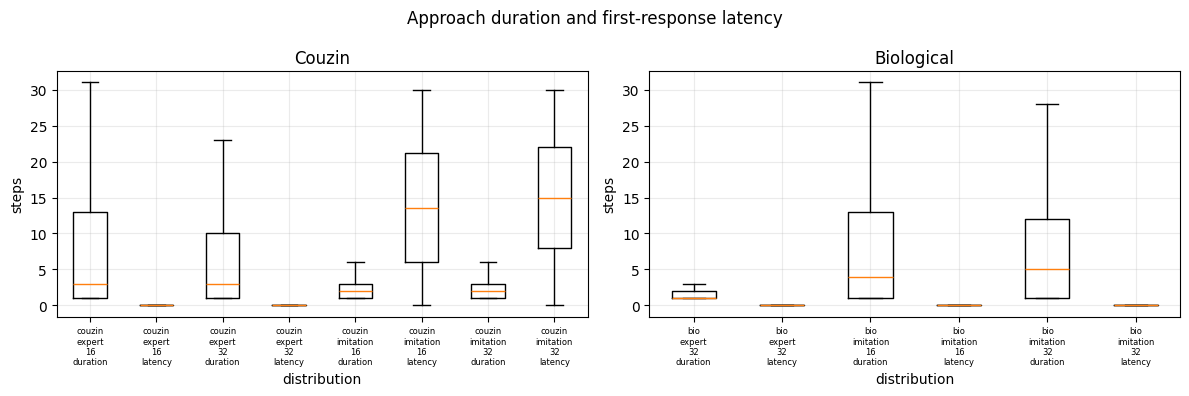

In [11]:
t0=perf_counter(); response_window={}; window_rows=[]; milestone_rows=[]; timing_rows=[]; timing_distributions={}
for name in CASE_ORDER:
    if name not in derived: continue
    curves=[]; available_all=[]; durations_all=[]; first_latency=[]
    for seg in derived[name]['response_segments']:
        windows,available,onsets,durations=event_windows(seg,REFERENCE_APPROACH_THRESHOLD,MAX_RESPONSE_WINDOW)
        if not len(windows): continue
        exceed=windows>REFERENCE_RESPONSE_THRESHOLD
        cumulative=exceed.cumsum(dim=1).clamp_max(1).float().mean(dim=2)
        cumulative[~available]=torch.nan
        curves.append(cumulative); available_all.append(available); durations_all.append(durations)
        any_step=exceed.any(dim=2)
        for row in any_step:
            idx=torch.nonzero(row).flatten(); first_latency.append(int(idx[0]) if len(idx) else -1)
    curves=torch.cat(curves) if curves else torch.empty((0,MAX_RESPONSE_WINDOW+1))
    available=torch.cat(available_all) if available_all else torch.empty((0,MAX_RESPONSE_WINDOW+1),dtype=torch.bool)
    durations=torch.cat(durations_all) if durations_all else torch.empty(0)
    mean=torch.nanmean(curves,dim=0) if len(curves) else torch.full((MAX_RESPONSE_WINDOW+1,),torch.nan)
    count=torch.isfinite(curves).sum(0) if len(curves) else torch.zeros(MAX_RESPONSE_WINDOW+1,dtype=torch.long)
    q25=torch.nanquantile(curves,.25,dim=0) if len(curves) else mean.clone()
    q75=torch.nanquantile(curves,.75,dim=0) if len(curves) else mean.clone()
    response_window[name]={'mean':mean,'q25':q25,'q75':q75,'count':count,'event_curves':curves}
    for k in range(MAX_RESPONSE_WINDOW+1):
        window_rows.append({'case':name,'step':k,'mean_cumulative_fraction':float(mean[k]),
                            'q25':float(q25[k]),'q75':float(q75[k]),'valid_events':int(count[k])})
    milestones={p:[] for p in (.5,.75,.9,.95)}
    for curve in curves:
        finite=torch.isfinite(curve); final=curve[finite][-1] if finite.any() else torch.tensor(0.)
        if final<=0: continue
        for p in milestones:
            hit=torch.nonzero(finite & (curve>=p*final)).flatten()
            if len(hit): milestones[p].append(int(hit[0]))
    for p,vals in milestones.items():
        v=torch.tensor(vals,dtype=torch.float32)
        milestone_rows.append({'case':name,'target_fraction_of_final':p,'responding_events':len(v),
            'median_step':float(v.median()) if len(v) else np.nan,'q75_step':float(torch.quantile(v,.75)) if len(v) else np.nan,
            'q90_step':float(torch.quantile(v,.9)) if len(v) else np.nan})
    lat=torch.tensor([x for x in first_latency if x>=0],dtype=torch.float32)
    timing_distributions[name]={'duration':durations.float(),'latency':lat}
    while_count=sum(1 for l,d in zip(first_latency,durations.tolist()) if l>=0 and l<d)
    after_count=sum(1 for l,d in zip(first_latency,durations.tolist()) if l>=0 and l>=d)
    timing_rows.append({'case':name,'events':len(first_latency),'responding_events':len(lat),
        'median_approach_duration':float(durations.float().median()) if len(durations) else np.nan,
        'median_first_latency':float(lat.median()) if len(lat) else np.nan,
        'response_while_approaching':while_count,'response_after_approach':after_count,
        'no_response_by_30':sum(x<0 for x in first_latency)})
runtime['response_window_and_timing']=perf_counter()-t0
fig,axes=two_panel(f'Cumulative response at approach={REFERENCE_APPROACH_THRESHOLD}, R>{REFERENCE_RESPONSE_THRESHOLD}',
                   'cumulative response fraction','steps after onset')
for name in CASE_ORDER:
    if name not in response_window: continue
    r=response_window[name]; x=torch.arange(len(r['mean']))
    ax=axes[0 if case_source(name)=='couzin' else 1]
    ax.plot(x,r['mean'],color=COLORS[case_style(name)],label=name.replace('_',' '))
    ax.fill_between(x,r['q25'],r['q75'],color=COLORS[case_style(name)],alpha=.12)
for ax in axes: ax.legend(frameon=False,fontsize=8)
fig.tight_layout(); plt.show()
display_table(window_rows,'Cumulative response and available events by step')
display_table(milestone_rows,'Response saturation milestones')
display_table(timing_rows,'Approach duration versus response timing')
fig,axes=two_panel('Approach duration and first-response latency','steps','distribution')
for ax,source in zip(axes,('couzin','biological')):
    names=[n for n in CASE_ORDER if n in timing_distributions and case_source(n)==source]
    data=[]; labels=[]
    for n in names:
        for key,label in (('duration','duration'),('latency','latency')):
            if len(timing_distributions[n][key]): data.append(timing_distributions[n][key].numpy()); labels.append(n.replace('_','\n')+'\n'+label)
    if data: ax.boxplot(data,tick_labels=labels,showfliers=False)
    ax.tick_params(axis='x',labelsize=6)
fig.tight_layout(); plt.show()


## Risk-bin validation

Equal-width bins cover the declared normalized range [0,1]. A bin is supported only when both its frame count and independent clip/rollout count meet the candidate criteria.

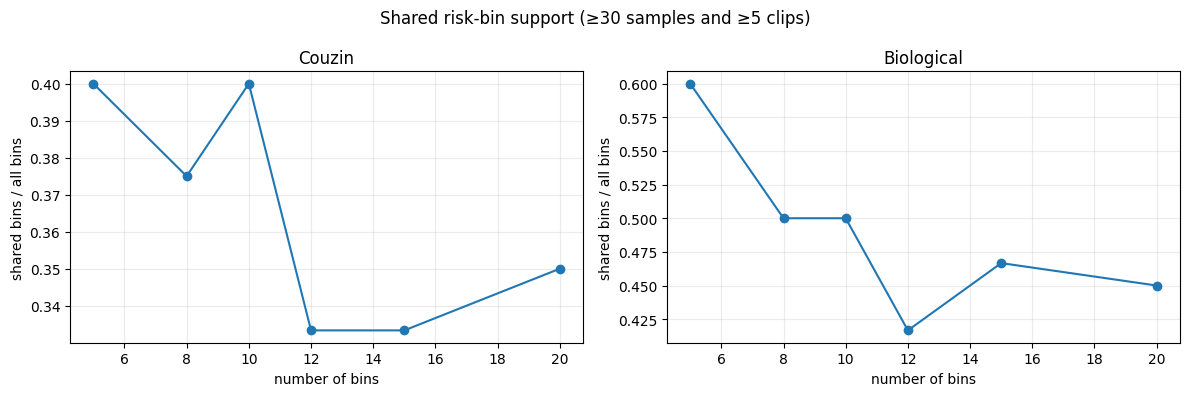

case,n_bins,bin,left,right,samples,clips,sample_fraction
couzin_expert_16,5,0,0,0.2,14054,20,0.7027
couzin_expert_16,5,1,0.2,0.4,3836,20,0.1918
couzin_expert_16,5,2,0.4,0.6,2061,20,0.10305
couzin_expert_16,5,3,0.6,0.8,49,11,0.00245
couzin_expert_16,5,4,0.8,1,0,0,0
couzin_expert_16,8,0,0,0.125,11622,20,0.5811
couzin_expert_16,8,1,0.125,0.25,3112,20,0.1556
couzin_expert_16,8,2,0.25,0.375,2549,20,0.12745
couzin_expert_16,8,3,0.375,0.5,2278,20,0.1139
couzin_expert_16,8,4,0.5,0.625,412,18,0.0206


source,n_bins,min_samples,min_clusters,expert_bins,imitation_bins,shared_bins,shared_risk_fraction
couzin,5,20,3,4,2,2,0.4
couzin,5,30,3,4,2,2,0.4
couzin,5,50,3,3,2,2,0.4
couzin,5,100,3,3,2,2,0.4
couzin,5,20,5,4,2,2,0.4
couzin,5,30,5,4,2,2,0.4
couzin,5,50,5,3,2,2,0.4
couzin,5,100,5,3,2,2,0.4
couzin,5,20,10,4,2,2,0.4
couzin,5,30,10,4,2,2,0.4


In [12]:
t0=perf_counter(); risk_bin_validation={'per_case':{},'shared':{}}; bin_rows=[]; shared_bin_rows=[]
for name in CASE_ORDER:
    if name not in derived: continue
    risk_bin_validation['per_case'][name]={}
    segs=derived[name]['distance_segments']
    for n_bins in N_BINS_CANDIDATES:
        edges=torch.linspace(0,1,n_bins+1); counts=torch.zeros(n_bins,dtype=torch.long); clip_sets=[set() for _ in range(n_bins)]
        for seg in segs:
            idx=pa.risk_bin_indices(seg['d_norm'],edges); valid=idx>=0
            counts+=torch.bincount(idx[valid],minlength=n_bins)
            for b in torch.unique(idx[valid]).tolist(): clip_sets[int(b)].add(seg['clip_id'])
        clusters=torch.tensor([len(x) for x in clip_sets]); risk_bin_validation['per_case'][name][n_bins]={'count':counts,'clusters':clusters}
        for b in range(n_bins):
            bin_rows.append({'case':name,'n_bins':n_bins,'bin':b,'left':float(edges[b]),'right':float(edges[b+1]),
                             'samples':int(counts[b]),'clips':int(clusters[b]),'sample_fraction':float(counts[b]/counts.sum().clamp_min(1))})
source_groups={
 'couzin':{'expert':['couzin_expert_16','couzin_expert_32'],'imitation':['couzin_imitation_16','couzin_imitation_32']},
 'biological':{'expert':['bio_expert_32'],'imitation':['bio_imitation_16','bio_imitation_32']}}
for source,groups in source_groups.items():
    risk_bin_validation['shared'][source]={}
    for n_bins in N_BINS_CANDIDATES:
        pooled={}
        for kind,names in groups.items():
            counts=sum((risk_bin_validation['per_case'][n][n_bins]['count'] for n in names if n in derived),torch.zeros(n_bins,dtype=torch.long))
            clusters=sum((risk_bin_validation['per_case'][n][n_bins]['clusters'] for n in names if n in derived),torch.zeros(n_bins,dtype=torch.long))
            pooled[kind]=(counts,clusters)
        for min_clusters in MIN_CLUSTERS_CANDIDATES:
            for min_samples in MIN_SAMPLES_CANDIDATES:
                ex=(pooled['expert'][0]>=min_samples)&(pooled['expert'][1]>=min_clusters)
                im=(pooled['imitation'][0]>=min_samples)&(pooled['imitation'][1]>=min_clusters)
                shared=ex&im
                row={'source':source,'n_bins':n_bins,'min_samples':min_samples,'min_clusters':min_clusters,
                     'expert_bins':int(ex.sum()),'imitation_bins':int(im.sum()),'shared_bins':int(shared.sum()),
                     'shared_risk_fraction':float(shared.float().mean())}
                shared_bin_rows.append(row); risk_bin_validation['shared'][source][(n_bins,min_samples,min_clusters)]=row
runtime['risk_bin_validation']=perf_counter()-t0
fig,axes=two_panel('Shared risk-bin support (≥30 samples and ≥5 clips)','shared bins / all bins','number of bins')
for ax,source in zip(axes,('couzin','biological')):
    vals=[risk_bin_validation['shared'][source][(n,30,5)]['shared_risk_fraction'] for n in N_BINS_CANDIDATES]
    ax.plot(N_BINS_CANDIDATES,vals,marker='o')
fig.tight_layout(); plt.show()
display_table(bin_rows,'Per-case risk-bin observations and independent support')
display_table(shared_bin_rows,'Shared Expert–Imitation bin support')


## Expert–Imitation shared support

Support is summarized after pooling cases only within the declared source and role. Separate case-level diagnostics above remain the basis for checking group-size differences.

source,expert_q01,expert_q99,imitation_q01,imitation_q99,shared_low,shared_high,positive_overlap
couzin,0.0144023,0.506164,0.008427701,0.2365716,0.0144023,0.2365716,True
biological,0.0307952,0.5367368,0.007678178,0.3913621,0.0307952,0.3913621,True


source,threshold,expert_events,expert_event_clips,imitation_events,imitation_event_clips,expert_frame_fraction,imitation_frame_fraction
couzin,0.05,1792,40,5479,40,0.1199,0.2033
couzin,0.075,2275,40,6963,40,0.24855,0.3162
couzin,0.1,2497,40,7626,40,0.343,0.3909
couzin,0.125,2598,40,7991,40,0.4248,0.4389
couzin,0.15,2651,40,8174,40,0.465425,0.46705
couzin,0.175,2699,40,8242,40,0.487225,0.481025
couzin,0.2,2743,40,8277,40,0.500875,0.488675
couzin,0.225,2811,40,8294,40,0.511225,0.4924
couzin,0.25,2894,40,8300,40,0.52,0.494075
couzin,0.275,2997,40,8302,40,0.52965,0.495


source,expert_q01,expert_q50,expert_q90,expert_q95,expert_q99,imitation_q01,imitation_q50,imitation_q90,imitation_q95,imitation_q99
couzin,-1.942611,0.005398124,0.2373907,0.2474822,1.945149,-1.797465,-0.003512561,0.03729236,0.04661349,0.06263182
biological,-0.2285126,-0.0001002252,0.03924781,0.07094175,0.2219838,-0.2410465,-0.0003815889,0.1040383,0.1433014,0.2137845


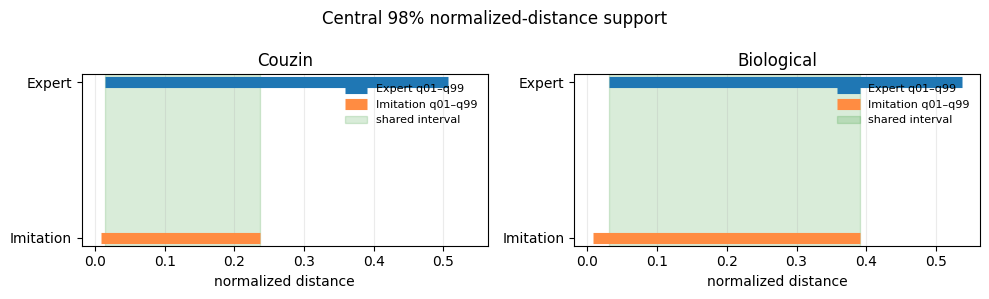

In [13]:
shared_support={'distance':{},'approach':{},'response':{}}
shared_distance_rows=[]; shared_approach_rows=[]; shared_response_rows=[]
for source,groups in source_groups.items():
    pooled={}
    for kind,names in groups.items():
        d=torch.cat([s['d_norm'] for n in names if n in derived for s in derived[n]['distance_segments']])
        r=torch.cat([s['response'].flatten() for n in names if n in derived for s in derived[n]['response_segments']])
        pooled[kind]={'distance':d,'response':r}
    exq=finite_quantiles(pooled['expert']['distance'],[.01,.99]); imq=finite_quantiles(pooled['imitation']['distance'],[.01,.99])
    overlap_low=max(float(exq[0]),float(imq[0])); overlap_high=min(float(exq[1]),float(imq[1]))
    shared_support['distance'][source]={'q01_q99_overlap':(overlap_low,overlap_high)}
    shared_distance_rows.append({'source':source,'expert_q01':float(exq[0]),'expert_q99':float(exq[1]),
        'imitation_q01':float(imq[0]),'imitation_q99':float(imq[1]),'shared_low':overlap_low,'shared_high':overlap_high,
        'positive_overlap':overlap_high>overlap_low})
    for athr in DISTANCE_THRESHOLDS:
        ex=[approach_sweep[n][athr] for n in groups['expert'] if n in approach_sweep]
        im=[approach_sweep[n][athr] for n in groups['imitation'] if n in approach_sweep]
        row={'source':source,'threshold':athr,'expert_events':sum(x['events'] for x in ex),
             'expert_event_clips':sum(x['event_clips'] for x in ex),'imitation_events':sum(x['events'] for x in im),
             'imitation_event_clips':sum(x['event_clips'] for x in im),
             'expert_frame_fraction':np.mean([x['frame_fraction'] for x in ex]) if ex else np.nan,
             'imitation_frame_fraction':np.mean([x['frame_fraction'] for x in im]) if im else np.nan}
        shared_approach_rows.append(row)
    exr=finite_quantiles(pooled['expert']['response'],[.01,.5,.9,.95,.99]); imr=finite_quantiles(pooled['imitation']['response'],[.01,.5,.9,.95,.99])
    row={'source':source,**{f'expert_{k}':float(v) for k,v in zip(('q01','q50','q90','q95','q99'),exr)},
         **{f'imitation_{k}':float(v) for k,v in zip(('q01','q50','q90','q95','q99'),imr)}}
    shared_response_rows.append(row)
display_table(shared_distance_rows,'Shared normalized-distance support (central 98%)')
display_table(shared_approach_rows,'Shared approach-event support')
display_table(shared_response_rows,'Expert–Imitation response-value support')
fig,axes=plt.subplots(1,2,figsize=(10,3),sharex=True)
for ax,(source,row) in zip(axes,zip(('couzin','biological'),shared_distance_rows)):
    ax.hlines(1,row['expert_q01'],row['expert_q99'],lw=8,color='#1f77b4',label='Expert q01–q99')
    ax.hlines(0,row['imitation_q01'],row['imitation_q99'],lw=8,color='#ff8c42',label='Imitation q01–q99')
    if row['positive_overlap']: ax.axvspan(row['shared_low'],row['shared_high'],color='green',alpha=.15,label='shared interval')
    ax.set(title=source.title(),xlabel='normalized distance',yticks=[0,1],yticklabels=['Imitation','Expert']); ax.grid(axis='x',alpha=.25); ax.legend(frameon=False,fontsize=8)
fig.suptitle('Central 98% normalized-distance support'); fig.tight_layout(); plt.show()


## Decision summary

These tables organize the evidence for discussion; they deliberately do not select a final threshold, window, bin count, or source-specific parameterization.

In [14]:
decision_approach=shared_approach_rows
decision_response=[]
for source,groups in source_groups.items():
    for rthr in RESPONSE_THRESHOLDS:
        rows={}
        for kind,names in groups.items():
            vals=[response_threshold_sweep[n][REFERENCE_APPROACH_THRESHOLD][rthr] for n in names if n in response_threshold_sweep]
            total_events=sum(v['events'] for v in vals)
            rows[kind]={'events':total_events,
                'observation_fraction':np.mean([v['observation_fraction'] for v in vals]) if vals else np.nan,
                'event_response_fraction':sum(v['mean_response_fraction']*v['events'] for v in vals)/max(total_events,1),
                'events_2plus':sum(v['events_2plus']*v['events'] for v in vals)/max(total_events,1)}
        decision_response.append({'source':source,'approach_reference':REFERENCE_APPROACH_THRESHOLD,'response_threshold':rthr,
            'expert_observation_fraction':rows['expert']['observation_fraction'],
            'imitation_observation_fraction':rows['imitation']['observation_fraction'],
            'expert_event_response_fraction':rows['expert']['event_response_fraction'],
            'imitation_event_response_fraction':rows['imitation']['event_response_fraction'],
            'expert_events_2plus':rows['expert']['events_2plus'],'imitation_events_2plus':rows['imitation']['events_2plus']})
decision_window=[]
for source,groups in source_groups.items():
    for step in (5,10,15,20,30):
        row={'source':source,'step':step}
        for kind,names in groups.items():
            blocks=[response_window[n] for n in names if n in response_window]
            num=sum(float(b['mean'][step])*int(b['count'][step]) for b in blocks if int(b['count'][step])>0)
            den=sum(int(b['count'][step]) for b in blocks)
            row[f'{kind}_mean_cumulative']=num/max(den,1); row[f'{kind}_valid_events']=den
        decision_window.append(row)
decision_bins=[r for r in shared_bin_rows if r['min_samples'] in (30,50) and r['min_clusters'] in (3,5,10)]
validation_results={
 'coverage':coverage,'distance_support':distance_support,'approach_threshold_sweep':approach_sweep,
 'closing_dynamics':{n:{k:v['summary'] for k,v in x.items()} for n,x in closing_dynamics.items()},
 'response_distribution':response_distribution,'response_threshold_sweep':response_threshold_sweep,
 'response_window':{n:{k:v for k,v in x.items() if k!='event_curves'} for n,x in response_window.items()},
 'risk_bin_validation':risk_bin_validation,'shared_support':shared_support,
 'decision_summary':{'approach':decision_approach,'response':decision_response,'window':decision_window,'bins':decision_bins}}
display_table(decision_approach,'A) Approach-distance evidence')
display_table(decision_response,'B) Response-threshold evidence')
display_table(decision_window,'C) Response-window evidence')
display_table(decision_bins,'D) Risk-bin evidence')


source,threshold,expert_events,expert_event_clips,imitation_events,imitation_event_clips,expert_frame_fraction,imitation_frame_fraction
couzin,0.05,1792,40,5479,40,0.1199,0.2033
couzin,0.075,2275,40,6963,40,0.24855,0.3162
couzin,0.1,2497,40,7626,40,0.343,0.3909
couzin,0.125,2598,40,7991,40,0.4248,0.4389
couzin,0.15,2651,40,8174,40,0.465425,0.46705
couzin,0.175,2699,40,8242,40,0.487225,0.481025
couzin,0.2,2743,40,8277,40,0.500875,0.488675
couzin,0.225,2811,40,8294,40,0.511225,0.4924
couzin,0.25,2894,40,8300,40,0.52,0.494075
couzin,0.275,2997,40,8302,40,0.52965,0.495


source,approach_reference,response_threshold,expert_observation_fraction,imitation_observation_fraction,expert_event_response_fraction,imitation_event_response_fraction,expert_events_2plus,imitation_events_2plus
couzin,0.15,0.025,0.41776,0.1959678,0.8972794,0.5384412,0.9996228,0.9985319
couzin,0.15,0.05,0.374584,0.0404115,0.8448345,0.2622186,0.9996228,0.9869097
couzin,0.15,0.075,0.3473403,0.003051489,0.8227202,0.02849355,0.9996228,0.1088818
couzin,0.15,0.1,0.3198034,0.0002479042,0.8048378,0.002588237,0.9996228,0.002569121
couzin,0.15,0.125,0.2915345,0.0001493681,0.7853994,0.001536885,0.9996228,0.001712748
couzin,0.15,0.15,0.2609469,0.0001274712,0.7652773,0.001292207,0.9988684,0.0006116956
couzin,0.15,0.175,0.226356,0.0001079204,0.7400391,0.00108576,0.9981139,0.0002446782
couzin,0.15,0.2,0.1865764,9.7754e-05,0.7046751,0.0009863592,0.9977367,0
biological,0.15,0.025,0.1524488,0.3266532,0.07839083,0.9213096,0.3440454,0.9983552
biological,0.15,0.05,0.0763954,0.2291682,0.03887051,0.7980057,0.2741021,0.9983552


source,step,expert_mean_cumulative,expert_valid_events,imitation_mean_cumulative,imitation_valid_events
couzin,5,0.6335432,2641,0.001408733,8119
couzin,10,0.8069476,2634,0.00261029,8081
couzin,15,0.9063808,2628,0.003810027,8038
couzin,20,0.9622201,2613,0.005054687,8000
couzin,30,0.9919792,2587,0.007451011,7910
biological,5,0.07291666,9,0.391537,1816
biological,10,0.1875,1,0.5376039,1805
biological,15,0,0,0.6308811,1796
biological,20,0,0,0.7000839,1788
biological,30,0,0,0.7948293,1772


source,n_bins,min_samples,min_clusters,expert_bins,imitation_bins,shared_bins,shared_risk_fraction
couzin,5,30,3,4,2,2,0.4
couzin,5,50,3,3,2,2,0.4
couzin,5,30,5,4,2,2,0.4
couzin,5,50,5,3,2,2,0.4
couzin,5,30,10,4,2,2,0.4
couzin,5,50,10,3,2,2,0.4
couzin,8,30,3,5,3,3,0.375
couzin,8,50,3,5,3,3,0.375
couzin,8,30,5,5,3,3,0.375
couzin,8,50,5,5,3,3,0.375


## Runtime summary

Coarse timings help identify unexpectedly expensive stages without adding profiler infrastructure.

In [15]:
runtime['total']=perf_counter()-t_total
runtime_rows=[{'stage':k,'seconds':v,'minutes':v/60} for k,v in runtime.items()]
display_table(runtime_rows,'Runtime summary')
print('Validation complete. No paper-analysis parameter or metric definition was modified.')


stage,seconds,minutes
loading_and_rollouts,0.576659,0.009610983
coverage_and_sequence_extraction,0.0001112,1.853333e-06
geometry_and_response,0.0003044,5.073333e-06
approach_threshold_sweep,20.82938,0.3471564
response_threshold_sweep,12.0347,0.2005783
response_window_and_timing,7.040573,0.1173429
risk_bin_validation,20.10953,0.3351589
total,90.5654,1.509423


Validation complete. No paper-analysis parameter or metric definition was modified.
